In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as img
import os
import cv2
import yaml
import shutil
from sklearn.model_selection import train_test_split

In [3]:
df_coords = pd.read_csv('/kaggle/input/datasets/sshikamaru/car-object-detection/data/train_solution_bounding_boxes (1).csv')

In [4]:
df_images = os.listdir('/kaggle/input/datasets/sshikamaru/car-object-detection/data/training_images')

In [5]:
coord_dict = {}
for index,row in df_coords.iterrows():
    image = row['image']
    box = (int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax']))
    if image not in coord_dict:
        coord_dict[image] = []
    coord_dict[image].append(box)

In [6]:
df_coords.shape, len(coord_dict), len(df_images)

((559, 5), 355, 1001)

In [7]:
images_dir = '/kaggle/input/datasets/sshikamaru/car-object-detection/data/training_images'
workdir = './txt_files'
os.makedirs(workdir, exist_ok=True)

In [8]:
for image_name,box in coord_dict.items():
    image = cv2.imread(os.path.join(images_dir, image_name))

    img_high, img_weight = image.shape[:2]
    file_name = image_name.replace('.jpg', '.txt')

    with open(f'{workdir}/{file_name}', 'w') as f:
        for i in box:
            xmin,ymin,xmax,ymax = i
            x_center = (xmax + xmin) / 2 / img_weight
            y_center = (ymax + ymin) / 2 / img_high
            weight = (xmax - xmin) / img_weight
            high = (ymax - ymin) / img_high
            f.write(f'0 {x_center:.6f} {y_center:.6f} {weight:.6f} {high:.6f}\n')
        

In [9]:
dataset_dir = '/kaggle/working/yolo_dataset'
for split in ['train', 'val']:
    os.makedirs(os.path.join(dataset_dir, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(dataset_dir, 'labels', split), exist_ok=True)
all_images = sorted([f for f in os.listdir(images_dir) if f.endswith('.jpg')])
images_with_labels = [img for img in all_images if img.replace('.jpg', '.txt') in os.listdir(workdir)]
train_imgs, val_imgs = train_test_split(images_with_labels, test_size=0.2, random_state=42)
def copy_files(img_list, split_name):
    for img_name in img_list:
        lbl_name = img_name.replace('.jpg', '.txt')
        src_img = os.path.join(images_dir, img_name)
        src_lbl = os.path.join(workdir, lbl_name)
        dst_img = os.path.join(dataset_dir, 'images', split_name, img_name)
        dst_lbl = os.path.join(dataset_dir, 'labels', split_name, lbl_name)
        shutil.copy(src_img, dst_img)
        shutil.copy(src_lbl, dst_lbl)
copy_files(train_imgs, 'train')
copy_files(val_imgs, 'val')

In [10]:
yaml_content = {
    'path': '/kaggle/working/yolo_dataset', 
    'train': 'images/train',                 
    'val': 'images/val',                    
    'names': {
        0: 'car'                           
    }
}
with open('/kaggle/working/dataset.yaml', 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False)

In [11]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [12]:
model = YOLO('yolov8n.pt')

results = model.train(data='/kaggle/working/dataset.yaml', epochs=10, imgsz=640, device=0, workers=0, cache=False )

Ultralytics 8.4.54 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

In [14]:
results_img_path = '/kaggle/working/runs/detect/train/results.png'

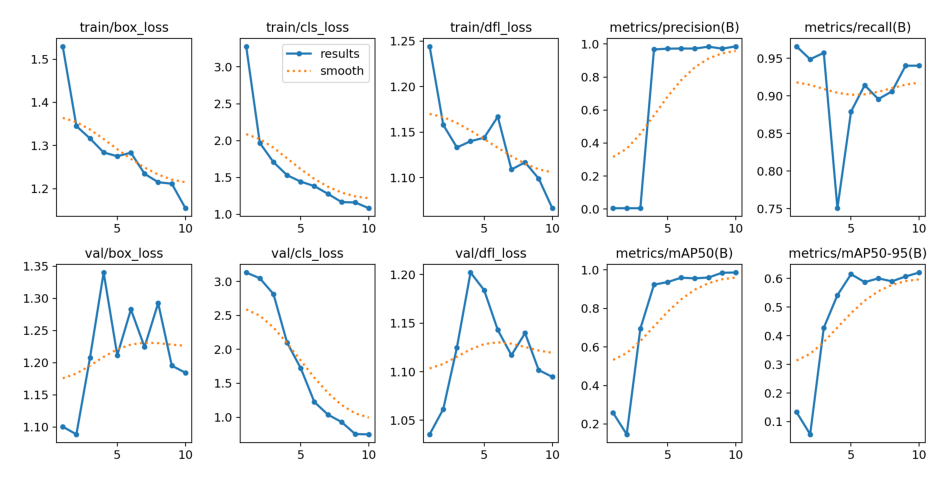

In [15]:
img = cv2.imread(results_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 12))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

In [16]:
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')
results = model.predict(
    source='/kaggle/input/datasets/sshikamaru/car-object-detection/data/testing_images', 
    save=True,   
    imgsz=640, 
    conf=0.4     
)


image 1/175 /kaggle/input/datasets/sshikamaru/car-object-detection/data/testing_images/vid_5_25100.jpg: 384x640 (no detections), 39.6ms
image 2/175 /kaggle/input/datasets/sshikamaru/car-object-detection/data/testing_images/vid_5_25120.jpg: 384x640 (no detections), 6.0ms
image 3/175 /kaggle/input/datasets/sshikamaru/car-object-detection/data/testing_images/vid_5_25140.jpg: 384x640 (no detections), 5.9ms
image 4/175 /kaggle/input/datasets/sshikamaru/car-object-detection/data/testing_images/vid_5_25160.jpg: 384x640 (no detections), 5.9ms
image 5/175 /kaggle/input/datasets/sshikamaru/car-object-detection/data/testing_images/vid_5_25180.jpg: 384x640 (no detections), 5.9ms
image 6/175 /kaggle/input/datasets/sshikamaru/car-object-detection/data/testing_images/vid_5_25200.jpg: 384x640 (no detections), 5.7ms
image 7/175 /kaggle/input/datasets/sshikamaru/car-object-detection/data/testing_images/vid_5_25220.jpg: 384x640 (no detections), 6.5ms
image 8/175 /kaggle/input/datasets/sshikamaru/car-obj

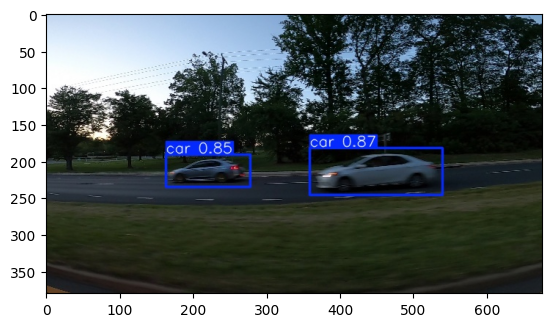

In [27]:
plt.imshow(img.imread('/kaggle/working/runs/detect/predict/vid_5_31600.jpg'))